In [9]:
from google.colab import files
uploaded = files.upload()

Saving sales_data_sample.csv to sales_data_sample.csv


In [11]:
import pandas as pd

df = pd.read_csv("sales_data_sample.csv", encoding="latin1")
df.head()

,ORDERNUMBER,QUANTITYORDERED,PRICEEACH,ORDERLINENUMBER,SALES,ORDERDATE,STATUS,QTR_ID,MONTH_ID,YEAR_ID,...,ADDRESSLINE1,ADDRESSLINE2,CITY,STATE,POSTALCODE,COUNTRY,TERRITORY,CONTACTLASTNAME,CONTACTFIRSTNAME,DEALSIZE
0,10107,30,95.70,2,2871.00,2/24/2003 0:00,Shipped,1,2,2003,...,897 Long Airport Avenue,NaN,NYC,NY,10022,USA,NaN,Yu,Kwai,Small
1,10121,34,81.35,5,2765.90,5/7/2003 0:00,Shipped,2,5,2003,...,59 rue de l'Abbaye,NaN,Reims,NaN,51100,France,EMEA,Henriot,Paul,Small
2,10134,41,94.74,2,3884.34,7/1/2003 0:00,Shipped,3,7,2003,...,27 rue du Colonel Pierre Avia,NaN,Paris,NaN,75508,France,EMEA,Da Cunha,Daniel,Medium
3,10145,45,83.26,6,3746.70,8/25/2003 0:00,Shipped,3,8,2003,...,78934 Hillside Dr.,NaN,Pasadena,CA,90003,USA,NaN,Young,Julie,Medium
4,10159,49,100.00,14,5205.27,10/10/2003 0:00,Shipped,4,10,2003,...,7734 Strong St.,NaN,San Francisco,CA,NaN,USA,NaN,Brown,Julie,Medium


In [12]:
df.head()
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2823 entries, 0 to 2822
Data columns (total 25 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   ORDERNUMBER       2823 non-null   int64  
 1   QUANTITYORDERED   2823 non-null   int64  
 2   PRICEEACH         2823 non-null   float64
 3   ORDERLINENUMBER   2823 non-null   int64  
 4   SALES             2823 non-null   float64
 5   ORDERDATE         2823 non-null   object 
 6   STATUS            2823 non-null   object 
 7   QTR_ID            2823 non-null   int64  
 8   MONTH_ID          2823 non-null   int64  
 9   YEAR_ID           2823 non-null   int64  
 10  PRODUCTLINE       2823 non-null   object 
 11  MSRP              2823 non-null   int64  
 12  PRODUCTCODE       2823 non-null   object 
 13  CUSTOMERNAME      2823 non-null   object 
 14  PHONE             2823 non-null   object 
 15  ADDRESSLINE1      2823 non-null   object 
 16  ADDRESSLINE2      302 non-null    object 


,0
ORDERNUMBER,0
QUANTITYORDERED,0
PRICEEACH,0
ORDERLINENUMBER,0
SALES,0
ORDERDATE,0
STATUS,0
QTR_ID,0
MONTH_ID,0
YEAR_ID,0


In [13]:
df.drop(['ADDRESSLINE2','STATE','TERRITORY','POSTALCODE','PHONE','ADDRESSLINE1'], axis=1, inplace=True)

In [14]:
df['ORDERDATE'] = pd.to_datetime(df['ORDERDATE'])

In [15]:
df['MONTH_YEAR'] = df['ORDERDATE'].dt.to_period('M')

In [16]:
df['SALES'].sum()

np.float64(10032628.85)

In [17]:
df['SALES'].mean()

np.float64(3553.889071909316)

In [18]:
df['ORDERNUMBER'].nunique()

307

In [19]:
df.groupby('PRODUCTLINE')['SALES'].sum().sort_values(ascending=False)

,SALES
PRODUCTLINE,
Classic Cars,3919615.66
Vintage Cars,1903150.84
Motorcycles,1166388.34
Trucks and Buses,1127789.84
Planes,975003.57
Ships,714437.13
Trains,226243.47


In [20]:
df.groupby('COUNTRY')['SALES'].sum().sort_values(ascending=False)

,SALES
COUNTRY,
USA,3627982.83
Spain,1215686.92
France,1110916.52
Australia,630623.10
UK,478880.46
Italy,374674.31
Finland,329581.91
Norway,307463.70
Singapore,288488.41


In [21]:
df.groupby('MONTH_YEAR')['SALES'].sum()

,SALES
MONTH_YEAR,
2003-01,129753.60
2003-02,140836.19
2003-03,174504.90
2003-04,201609.55
2003-05,192673.11
2003-06,168082.56
2003-07,187731.88
2003-08,197809.30
2003-09,263973.36


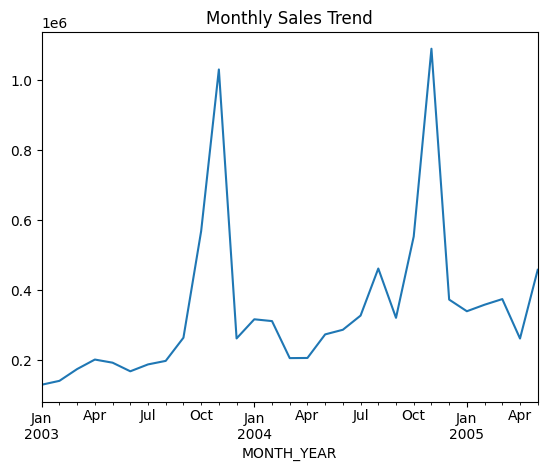

In [22]:
import matplotlib.pyplot as plt

df.groupby('MONTH_YEAR')['SALES'].sum().plot(kind='line')
plt.title("Monthly Sales Trend")
plt.show()

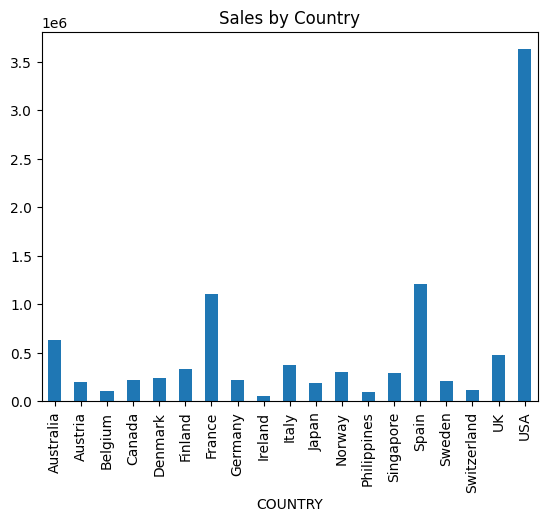

In [23]:
df.groupby('COUNTRY')['SALES'].sum().plot(kind='bar')
plt.title("Sales by Country")
plt.show()

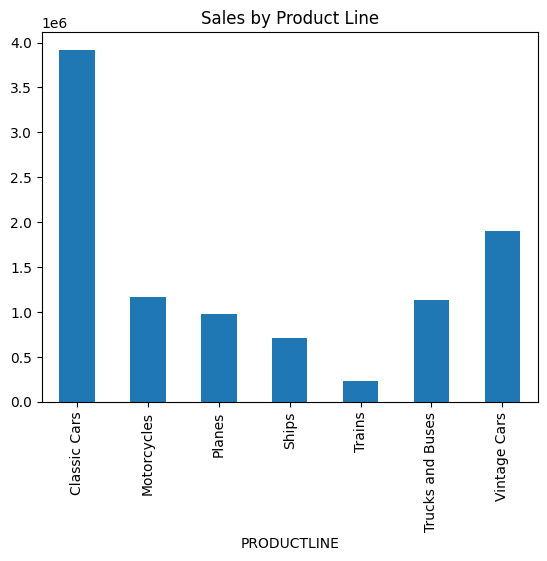

In [24]:
df.groupby('PRODUCTLINE')['SALES'].sum().plot(kind='bar')
plt.title("Sales by Product Line")
plt.show()

In [25]:
df.to_csv("cleaned_sales_data.csv", index=False)